## Load Data

In [63]:
# Import Library
import pandas as pd

In [64]:
# Menampilkan dan Membaca Data
df_buah = pd.read_csv('citrus.csv')
df_buah.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [65]:
# Menampilkan Info
df_buah.info()

# Menampilkan Describe
df_buah.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


,diameter,weight,red,green,blue
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,9.98,175.05,153.85,76.01,11.36
std,1.95,29.21,10.43,11.71,9.06
min,2.96,86.76,115.00,31.00,2.00
25%,8.46,152.22,147.00,68.00,2.00
50%,9.98,174.98,154.00,76.00,10.00
75%,11.48,197.72,161.00,84.00,17.00
max,16.45,261.51,192.00,116.00,56.00


In [66]:
# Melihat Jumlah Duplikat
print(f'Jumlah Duplikat : {df_buah.duplicated().sum()}')

Jumlah Duplikat : 0


## EDA

In [67]:
# Import Library
import seaborn as sns
import matplotlib.pyplot as plt
import math

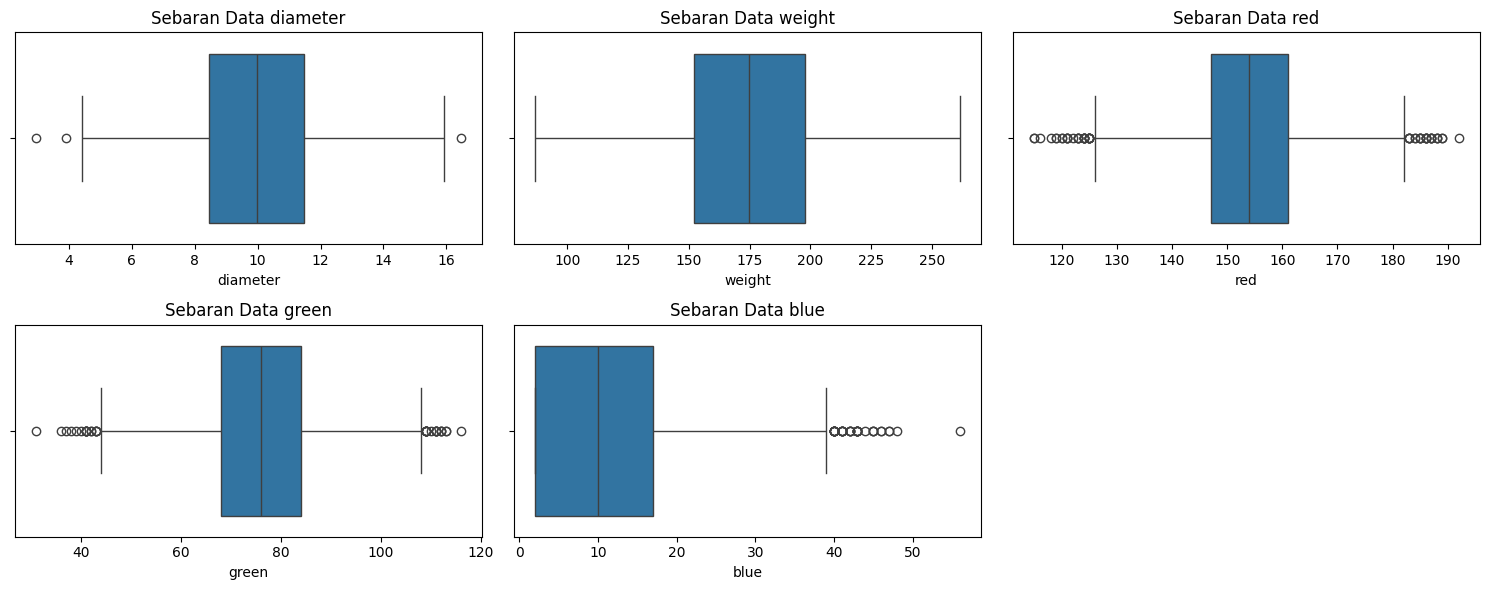

In [68]:
kolom_numerik = df_buah.select_dtypes(include=['int64', 'float64']).columns

# Visualisasi Melihat Outlier
jumlah_kolom = 3
jumlah_baris = math.ceil(len(kolom_numerik) / jumlah_kolom)

# Membuat Canvas
fig, ax = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(15,6))
ax=ax.flatten()

# Looping Visualisasi
for i, kolom in enumerate(kolom_numerik) : 
    sns.boxplot(data=df_buah, x=kolom, ax=ax[i])
    ax[i].set_title(f'Sebaran Data {kolom}')

# Menghapus Sisa Visualisasi
for i in range(len(kolom_numerik), len(ax)) : 
    fig.delaxes(ax[i])

# Menampilkan Visualisasi Hitsplot
plt.tight_layout()
plt.show()

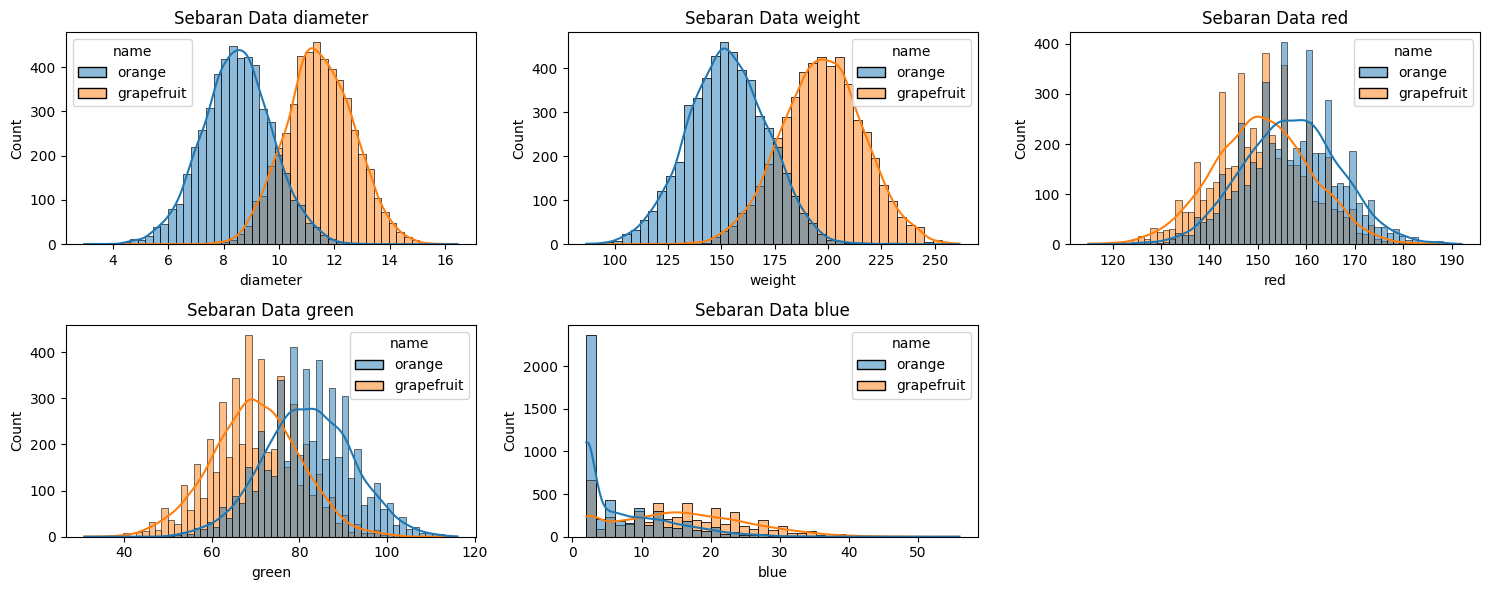

In [69]:
# Menentukan Jumlah Baris dan Kolom
jumlah_kolom = 3
jumlah_baris = math.ceil(len(kolom_numerik) / jumlah_kolom)

# Membuat Canvas
fig, ax = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(15,6))
ax=ax.flatten()

# Looping Visualisasi
for i, kolom in enumerate(kolom_numerik) : 
    sns.histplot(data=df_buah, x=kolom, ax=ax[i], kde=True, hue='name')
    ax[i].set_title(f'Sebaran Data {kolom}')

# Menghapus Sisa Visualisasi
for i in range(len(kolom_numerik), len(ax)) : 
    fig.delaxes(ax[i])
    
# Menampilkan Visualisasi Hitsplot
plt.tight_layout()
plt.show()

In [ ]:
# Melihat Nilai Yang Keluar Dari Whisker
Q1 = df_buah['blue'].quantile(0.25)
Q3 = df_buah['blue'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df_buah[(df_buah['blue'] < batas_bawah) | (df_buah['blue'] > batas_atas)]

print("Jumlah outlier:", len(outlier))
outlier.head()

Jumlah outlier: 36


,name,diameter,weight,red,green,blue
5014,0,8.29,146.51,168,86,42
5028,0,8.59,149.20,146,82,40
5045,0,8.75,151.29,154,53,41
5127,0,9.12,159.39,146,50,41
5133,0,9.13,159.61,143,75,40


## Encoding Label

In [70]:
# Import Library
from sklearn.preprocessing import LabelEncoder

# Encoding Label Target
le = LabelEncoder()
df_buah['name'] = le.fit_transform(df_buah['name'])

df_buah.head()

,name,diameter,weight,red,green,blue
0,1,2.96,86.76,172,85,2
1,1,3.91,88.05,166,78,3
2,1,4.42,95.17,156,81,2
3,1,4.47,95.60,163,81,4
4,1,4.48,95.76,161,72,9


In [71]:
# Mapping label
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapping Label:', label_mapping)

Mapping Label: {'grapefruit': 0, 'orange': 1}


## Splitting

In [72]:
# Import Library
from sklearn.model_selection import train_test_split

# Menentukan Kolom Target dan Fitur
X = df_buah.drop('name', axis=1)
y = df_buah['name']

# Splitting Data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 32)

In [73]:
# Menampilkan Jumlah Data Latihan dan Data Test
print(f'Jumlah Data Latihan : {len(x_train)}')
print(f'Jumlah Data Test : {len(x_test)}')

Jumlah Data Latihan : 8000
Jumlah Data Test : 2000


## Scalling

In [74]:
# Import Library
from sklearn.preprocessing import StandardScaler

# Standardisasi 
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Melatih Model

In [75]:
# Import Library
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [76]:
# Fungsi Evaluasi Klasifikasi
def hasil_evaluasi(model, prediksi_latihan, prediksi_test) : 
    # Melihat Akurasi
    akurasi_latihan = accuracy_score(y_train, prediksi_latihan)
    akurasi_test = accuracy_score(y_test, prediksi_test)

    # Menampilkan Data
    print(f'Akurasi Data Latihan : {akurasi_latihan : .2f}')
    print(f'Akurasi Data Test : {akurasi_test : .2f}\n')

    # Melihat Classification Report
    print(classification_report(y_test, prediksi_test, target_names = le.classes_))

In [77]:
# Visualisasi Confusion Matrix
def visualisasi_confusion_matrix(model, prediksi_test) : 
    # Membuat Confusion Matrix
    cm = confusion_matrix(y_test, prediksi_test)

    # Membuat Heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(f'Confusion Matrix - {model}')
    plt.show()

### Decission Tree

In [78]:
# Import Library
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi Model
model_dt = DecisionTreeClassifier()

# Melatih Model
model_dt.fit(x_train, y_train)

# Memprediksi Model
pred_latihan_dt = model_dt.predict(x_train)
pred_test_dt = model_dt.predict(x_test)

In [79]:
# Menampilkan Hasil Evaluasi
hasil_evaluasi(model_dt, pred_latihan_dt, pred_test_dt)

Akurasi Data Latihan :  1.00
Akurasi Data Test :  0.94

              precision    recall  f1-score   support

  grapefruit       0.95      0.94      0.95      1011
      orange       0.94      0.95      0.94       989

    accuracy                           0.94      2000
   macro avg       0.94      0.95      0.94      2000
weighted avg       0.95      0.94      0.95      2000



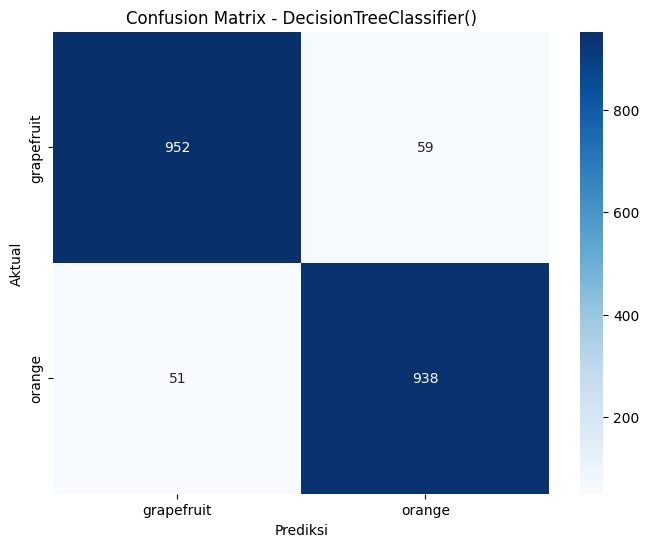

In [80]:
# Menampilkan Visualisasi Matrix
visualisasi_confusion_matrix(model_dt, pred_test_dt)

## Naive Bayes

In [81]:
# Import Library
from sklearn.naive_bayes import GaussianNB

# Inisialisasi Model
model_nb = GaussianNB()

# Melatih Model
model_nb.fit(x_train, y_train)

# Memprediksi Model
pred_latihan_nb = model_nb.predict(x_train)
pred_test_nb = model_nb.predict(x_test)

In [82]:
# Menampilkan Hasil Evaluasi
hasil_evaluasi(model_nb, pred_latihan_nb, pred_test_nb)

Akurasi Data Latihan :  0.92
Akurasi Data Test :  0.92

              precision    recall  f1-score   support

  grapefruit       0.92      0.91      0.92      1011
      orange       0.91      0.92      0.92       989

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



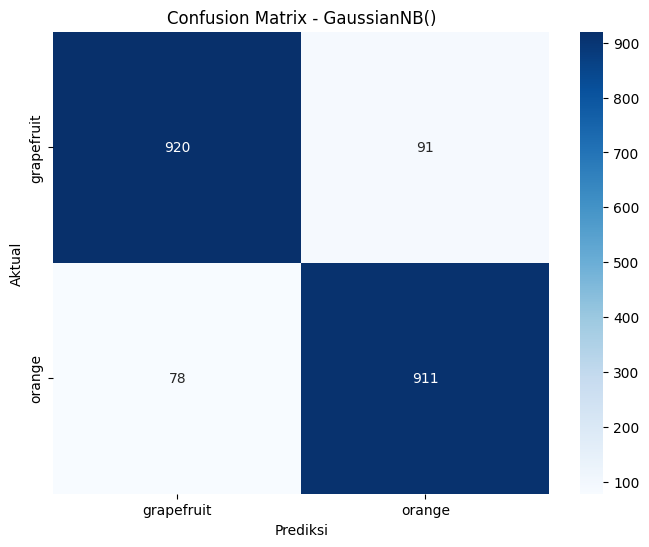

In [83]:
# Menampilkan Visualisasi Matrix
visualisasi_confusion_matrix(model_nb, pred_test_nb)

## Support Vector Machine

In [84]:
# Import Library
from sklearn.svm import SVC

# Inisialisasi Model
model_svm = SVC()

# Melatih Model
model_svm.fit(x_train, y_train)

# Memprediksi Model
pred_latihan_svm = model_svm.predict(x_train)
pred_test_svm = model_svm.predict(x_test)

In [85]:
# Menampilkan Hasil Evaluasi
hasil_evaluasi(model_svm, pred_latihan_svm, pred_test_svm)

Akurasi Data Latihan :  0.94
Akurasi Data Test :  0.93

              precision    recall  f1-score   support

  grapefruit       0.93      0.93      0.93      1011
      orange       0.93      0.93      0.93       989

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



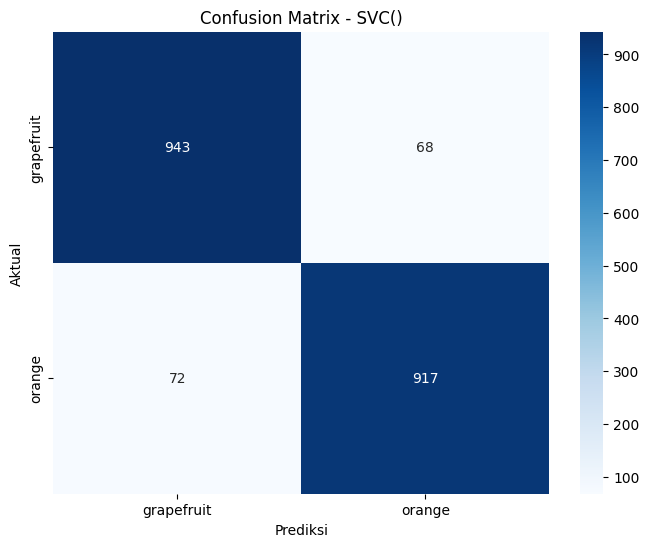

In [86]:
# Menampilkan Visualisasi Matrix
visualisasi_confusion_matrix(model_svm, pred_test_svm)

## Hasil Perbandingn

In [87]:
# Melihat Akurasi Data Latihan
akurasi_lat_dt = accuracy_score(y_train, pred_latihan_dt)
akurasi_lat_nb = accuracy_score(y_train, pred_latihan_nb)
akurasi_lat_svm = accuracy_score(y_train, pred_latihan_svm)

# Melihat Akurasi Data Test
akurasi_test_dt = accuracy_score(y_test, pred_test_dt)
akurasi_test_nb = accuracy_score(y_test, pred_test_nb)
akurasi_test_svm = accuracy_score(y_test, pred_test_svm)


tabel = {
    'Model' : ['Decision Tree', 'Naive Bayes', 'Support Vector Machine'],
    'Akurasi Latihan' : [akurasi_lat_dt, akurasi_lat_nb, akurasi_lat_svm],
    'Akurasi Test' : [akurasi_test_dt, akurasi_test_nb, akurasi_test_svm]
}

# Membuat DataFrame
df_hasil = pd.DataFrame(tabel)
df_hasil.round(2)

,Model,Akurasi Latihan,Akurasi Test
0,Decision Tree,1.00,0.94
1,Naive Bayes,0.92,0.92
2,Support Vector Machine,0.94,0.93
